# Examining the ratio of the small ions:

Here we produce the figures:

- Figure 6
- Figure S24



In [1]:
import glob
import xarray as xr
from sklearn.linear_model import LinearRegression
import math
import datetime 
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from xarray.plot.utils import _infer_interval_breaks as infer_interval_breaks
import pandas as pd
import os
import matplotlib.dates as dts
from matplotlib.colors import LogNorm, Normalize
import matplotlib.dates as md
import re
from scipy.stats import linregress
from datetime import datetime, timedelta
import scipy.io
from pathlib import Path

plt.rcParams["font.family"] = 'monospace'

In [2]:
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
analysis_file_path = project_root / 'Analysis' 
plots_outpath = project_root / 'Plots'

In [3]:
path_for_events = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\event_days_nc'
print(path_for_events)
save_folder_nanoranking=r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\Nano_ranking'
print(save_folder_nanoranking)

loadpath_checked_start_end_times = r'C:\Users\Dell\Documents\NAIS_work\Classification'
checked_start_end_times_filename='events_start_and_end_times_checked.xlsx' 

files = glob.glob(path_for_events+'\\*.nc')
XR_resampled = xr.open_dataset(files[0])

C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\event_days_nc
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\Nano_ranking


In [4]:
def save_plot(fig, filepath, dpi=300):
    """
    Save figure to file with automatic directory creation.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    filepath : str or Path
        Full path where to save the figure (e.g., 'path/to/figure.jpeg')
    dpi : int, optional
        Resolution in dots per inch (default: 300)
    """
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    print(f"Saved: {filepath}")

# load data: 
and combine NAIS and DMPS data

In [5]:
def from_Dp2lDp(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset,
xr.DataArray]:
    """
    Convert particle diameter to log10(particle diameter)

    Parameters
    ----------
    o : xr.Dataset
        Dataset with a 'Dp' variable

    Returns
    -------
    xr.Dataset
        Dataset with a 'lDp' variable added,
        where 'lDp' is the base-10 logarithm of 'Dp'.
    """
    lDp = np.log10(o['Dp'])
    o = o.assign_coords({'lDp': lDp})
    return o

def set_lDp(o):
    dims = list(o.dims)
    coords = list(o.coords)
    # o_coords = set(coords)-set(dims)
    if 'lDp' not in coords:
        o = from_Dp2lDp(o)
    if 'lDp' not in dims:
        o = o.swap_dims({'Dp': 'lDp'})
    return o

def dp_regrid(da, *, n_subs, log_dy):

    if isinstance(da, xr.DataArray):
        assert da.name == 'dndlDp'
        da_ = da
    elif isinstance(da, xr.Dataset):
        da_ = da['dndlDp']

    # Keep original time coordinate
    time = da_.time

    # Convert Dp -> lDp
    ds1 = set_lDp(da_).reset_coords(drop=True)

    # Fine-grid spacing
    dy = log_dy / n_subs

    # Original lDp interval boundaries
    ints = infer_interval_breaks(
        ds1['lDp'],
        check_monotonic=True
    )

    ym_ = float(ints[0])
    yM_ = float(ints[-1])

    # Align fine grid with dy
    ym = np.round(ym_ / dy) * dy
    yM = np.round(yM_ / dy) * dy

    # Fine lDp grid
    yl = np.arange(
        ym,
        yM + dy / 2,
        dy
    )

    # Interpolate
    d1 = ds1.interp(
        lDp=yl,
        kwargs=dict(fill_value="extrapolate")
    )

    # Number of complete output bins
    n_bins = len(yl) // n_subs

    # Discard incomplete final bin
    d1 = d1.isel(
        lDp=slice(0, n_bins * n_subs)
    )

    # ---------------------------------------------------------
    # Reshape:
    #
    # (time, fine_lDp)
    #
    #        ↓
    #
    # (time, lDp_bin, sub)
    # ---------------------------------------------------------

    values = d1.values.reshape(
        len(time),
        n_bins,
        n_subs
    )

    # Mean over subintervals
    values = values.mean(axis=2)

    # Output lDp coordinates
    lDp = (
        ym
        + (np.arange(n_bins) + 0.5) * log_dy
    )

    # Construct output explicitly
    dsout = xr.DataArray(
        values,
        dims=('time', 'lDp'),
        coords={
            'time': time,
            'lDp': lDp,
        },
        name='dndlDp',
        attrs=da_.attrs,
    )

    return dsout

def from_lDp2Dp(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset,
xr.DataArray]:
    """
    Convert log10(particle diameter) to particle diameter

    Parameters
    ----------
    o : xr.Dataset
        Dataset with a 'lDp' variable

    Returns
    -------
    xr.Dataset
        Dataset with a 'Dp' variable added,
        where 'Dp' is the base-10 exponential of 'lDp'.
    """
    Dp = 10 ** (o['lDp'])
    o = o.assign_coords({'Dp': Dp})
    return o


def set_sec(o):
    dims = list(o.dims)
    coords = list(o.coords)
    # o_coords = set(coords)-set(dims)
    if 'secs' not in coords:
        o = from_time2sec(o)
    if 'secs' not in dims:
        o = o.swap_dims({'time': 'secs'})
    return o

def from_sec2time(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset, xr.DataArray]:
    """
    Convert seconds since 1970-01-01 to time

    Parameters
    ----------
    o : Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'secs' coordinate

    Returns
    -------
    Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'time' coordinate added,
        where 'time' is the date and time corresponding to the
        number of seconds since 1970-01-01.
    """
    secs = o['secs'].astype('datetime64[s]')
    o = o.assign_coords({'time': secs})
    return o

def from_time2sec(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset, xr.DataArray]:
    """
    Convert time to seconds since 1970-01-01

    Parameters
    ----------
    o : Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'time' coordinate

    Returns
    -------
    Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'secs' coordinate added,
        where 'secs' is the time in seconds since 1970-01-01.
    """
    date = o['time']
    # handle numeric time coordinates (already seconds) or datetime64 with various units
    vals = date.values
    # numeric type: assume seconds since epoch already
    if np.issubdtype(vals.dtype, np.number):
        secs = vals.astype('float64')
    else:
        # try to compute seconds since UNIX epoch robustly
        try:
            epoch = np.datetime64('1970-01-01T00:00:00')
            secs = (vals - epoch) / np.timedelta64(1, 's')
        except Exception:
            # fallback: use pandas to_datetime then convert to seconds
            try:
                secs = pd.to_datetime(vals).astype('int64') / 1e9
            except Exception:
                # last resort: attempt matplotlib date2num then convert days to seconds
                try:
                    import matplotlib.dates as mdates
                    secs = (mdates.date2num(vals) - mdates.date2num(np.datetime64('1970-01-01'))) * 86400.0
                except Exception:
                    raise ValueError('Unsupported time coordinate dtype for from_time2sec: %s' % (vals.dtype,))

    # assign secs coordinate aligned with the time dimension
    o = o.assign_coords({'secs': (date.dims, secs)})
    return o

def set_time(o):
    dims = list(o.dims)
    coords = list(o.coords)
    # o_coords = set(coords)-set(dims)

    if 'time' not in coords:
        o = from_sec2time(o)

    if 'time' not in dims:
        o = o.swap_dims({'secs': 'time'})

    return o

def set_Dp(o):
    dims = list(o.dims)
    coords = list(o.coords)
    if 'Dp' not in coords:
        # print(coords)
        o = from_lDp2Dp(o)
    if 'Dp' not in dims:
        o = o.swap_dims({'lDp': 'Dp'})
    return o

def upsample_ts(o, dt):
    dt = float(dt)
    orgi_dt = set_sec(o)['secs'].diff('secs').mean().item()
    assert dt <= orgi_dt, 'you are trying to upsample when you should be downsampling'
    orig_dim = list(o.dims)
    print('original dims:', orig_dim)
    o = set_time(o)
    o = o.resample({'time': pd.Timedelta(dt, unit='s')}).interpolate('linear')
    if 'time' in orig_dim:
        o = set_time(o)
    if 'secs' in orig_dim:
        o = set_sec(o)
    return o

In [6]:
def rename_resample_xr(XR_resampled, polarity='neg', mode='particles', resolution='15T', 
                           average='median'):
    xr_nais = XR_resampled[str(polarity)+'_'+str(mode)].to_pandas()
    #resample to 15 minutes
    if average == 'mean':
        ds_ = xr_nais.stack().to_xarray().rename({'diameter':'Dp'}).assign_coords({'Dp':lambda d:d['Dp'].astype(float)}).rename('dndlDp').sortby('time').resample({'time':resolution}).mean()
    if average == 'median':
        ds_ = xr_nais.stack().to_xarray().rename({'diameter':'Dp'}).assign_coords({'Dp':lambda d:d['Dp'].astype(float)}).rename('dndlDp').sortby('time').resample({'time':resolution}).median()
    ds_.drop_duplicates(dim='time')
    return ds_

def regrid_ds(ds_):
    ## regridding ppsamples a time series with a given time step. Regrids the diameter distribution of 40 to 27
    ds = (ds_.pipe(dp_regrid, log_dy=.05, n_subs=10).pipe(set_Dp))    
    return ds

def interpolate_ds(ds, minutes=15):
    ds=ds.pipe(upsample_ts, dt=minutes*60) #linear interpolation
    ds = ds.to_dataset()
    return ds

In [7]:
########### LOAD 5 MINUTE NAIS DATA ####################################################################
resolution = '5min'
path = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\resampled\resampled_removed_snow_clouds_bad_charged'
XR_resampled = xr.open_dataset(path+'\\'+str(resolution)+'_removed_snow_clouds_bad_charged.nc')
polarity='neg';
mode='particles'

In [8]:
def save_ds_file(ds, save_folder, polarity = 'neg', mode = 'particles', 
                    average = 'median'):
    print(save_folder) 
    #save
    if polarity == 'neg':
        polarity_name = 'np'
    if polarity == 'pos':
        polarity_name = 'pp'
    if mode == 'particles':
        mode_name = 'par'
    if mode == 'ions':
        mode_name = 'ion'
    i = 1
    try:        
        file = str(polarity_name)+"_"+str(mode_name)+"-zep-nais_"+str(average)+'_'+str(i)+".nc"
        print(save_folder+file)        
        ds.to_netcdf(save_folder+file)    
    except:
        i=i+1        
        file = str(polarity_name)+"_"+str(mode_name)+"-zep-nais_"+str(average)+'_'+str(i)+".nc"
        print(save_folder+file)        
        ds.to_netcdf(save_folder+file)      

In [9]:
########## REGRID AND INTERPOLATE 5 MINUTE NAIS DATA TO 15 MINUTES ####################################################################
ds_nais_neg = rename_resample_xr(XR_resampled, polarity='neg', mode='ions', 
                             resolution='15min', average='median')
ds_nais_neg = regrid_ds(ds_nais_neg)
ds_nais_neg =  interpolate_ds(ds_nais_neg, minutes=15)

id='neg_ions'
ds_nais_neg = ds_nais_neg.expand_dims({'id':[id]})

save_ds_file(ds_nais_neg, save_folder_nanoranking,  
                    polarity = 'neg', mode = 'ions', 
                    average = 'median')

ds_nais_neg = ds_nais_neg.drop_vars('lDp')

original dims: ['time', 'Dp']
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\Nano_ranking
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\Nano_rankingnp_ion-zep-nais_median_1.nc


In [10]:
########## REGRID AND INTERPOLATE 5 MINUTE NAIS DATA TO 15 MINUTES ####################################################################
ds_nais_pos = rename_resample_xr(XR_resampled, polarity='pos', mode='ions', 
                             resolution='15min', average='median')
ds_nais_pos = regrid_ds(ds_nais_pos)
ds_nais_pos =  interpolate_ds(ds_nais_pos, minutes=15)
id='pos_ions'
ds_nais_pos = ds_nais_pos.expand_dims({'id':[id]})
save_ds_file(ds_nais_pos, save_folder_nanoranking,  
                    polarity = 'pos', mode = 'ions', 
                    average = 'median')
ds_nais_pos = ds_nais_pos.drop_vars('lDp')

original dims: ['time', 'Dp']
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\Nano_ranking
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\Nano_rankingpp_ion-zep-nais_median_1.nc


In [11]:
ds_nais_ions = (xr.concat([ds_nais_neg, ds_nais_pos], dim='id'))
ds_nais_ions = ds_nais_ions.loc[{'time':slice('2022-04-17','2024-10-04')}]

In [12]:
def plot_size_distribution(nais_xr, time_var='time', fs_label=12, 
                           ymin=10**(-1), ymax=10**4, diameters_ticks=None, average = 'median'):
    fig, ax = plt.subplots(figsize=(7,3))
    
    if average == 'mean':
        nais_xr_pos = nais_xr.loc[{'id':'pos_ions'}].copy()
        nais_xr_pos['dndlDp'].mean(time_var).plot(yscale='log',xscale='log', c='r', label='+')
        nais_xr_neg = nais_xr.loc[{'id':'neg_ions'}].copy()
        nais_xr_neg['dndlDp'].mean(time_var).plot(yscale='log',xscale='log', c='b', label='-')
    if average == 'median':
        nais_xr_pos = nais_xr.loc[{'id':'pos_ions'}].copy()
        nais_xr_pos['dndlDp'].median(time_var).plot(yscale='log',xscale='log', c='r', label='+')
        nais_xr_neg = nais_xr.loc[{'id':'neg_ions'}].copy()
        nais_xr_neg['dndlDp'].median(time_var).plot(yscale='log',xscale='log', c='b', label='-')

    ax.set_ylabel('dN/dlogD$_\\mathrm{p}$ [$\\mathrm{cm}^{-3}$]', fontsize=15) 
    ax.set_xlabel('D$_{\\mathrm{p}}$ [m]', fontsize=15)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='both', length=0.4, width=1)
    ax.legend(frameon=False, fontsize=25)
    ax.vlines(x=2e-9, ymin=10**(-3), ymax=1000, ls=':', color='k')
    ax.set_ylim(ymin, ymax)
    if diameters_ticks is not None:        
        xticks = [x*10**(-9) for x in diameters_ticks]
        ax.set_xticks(xticks)
        ax.set_xticklabels(diameters_ticks, fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.tick_params(axis='both', which='minor', labelsize=15)
    thickax(ax, fontsize=fs_label)
    ax.set_title('')
    plt.show()
    return fig

In [13]:
def get_diameters(XR_nais, diameter_var='diameter'):
    Dp = XR_nais[diameter_var][:].values
    Dp_int = [x*10**9 for x in Dp]
    Dp_int_2dp = [float("{:.2f}".format(x)) for x in Dp_int]
    print("Bins: "+str(Dp_int_2dp))
    return Dp_int

def calculate_binwidth(bins):
    dlog=[] #this is the final list of bin widths
    midpoints=[] #these are upper and lower bin boundaries
    for x in range(len(bins)-1):
        midpoints.append(np.sqrt(bins[x+1]*bins[x])) 
    midpoints.insert(0,bins[0]-(midpoints[0]-bins[0])) #add extra lowest boundary
    midpoints.append(bins[-1]+(bins[-1]-midpoints[-1])) #add extra higherst boundary
    midpoints
    for i in range(len(bins)):
        binwidths = np.log10(midpoints[i+1])-np.log10(midpoints[i])
        dlog.append(binwidths)
    dlog
    return dlog

def slice_xr(nais_xr, start=None, stop=None):
    return nais_xr.loc[dict(time=slice(start, stop))]

In [14]:
def get_n(ds_event_cleaned_ions, min_size=2, max_size=4, diameter_var='diameter',
          var='dndlDp'):
    Dp_int = get_diameters(ds_event_cleaned_ions,diameter_var=diameter_var)
    dlogs = calculate_binwidth(Dp_int)
    ds_event_cleaned_ions[var] = ds_event_cleaned_ions[var][:, :]*dlogs
    sliced_xr = slice_xr(ds_event_cleaned_ions).loc[{diameter_var:slice(min_size*10**(-9),max_size*10**(-9))}].sum(diameter_var).copy()
    return sliced_xr

In [15]:
nais_xr_pos = ds_nais_ions.loc[{'id':'pos_ions'}].copy()
n_pos_ions = get_n(nais_xr_pos, min_size=2, max_size=4, diameter_var='Dp',
                  var='dndlDp')

nais_xr_neg = ds_nais_ions.loc[{'id':'neg_ions'}].copy()
n_neg_ions = get_n(nais_xr_neg, min_size=2, max_size=4, diameter_var='Dp',
                  var='dndlDp')

neg_pos_ratio_CF = float(n_neg_ions['dndlDp'].sum()/n_pos_ions['dndlDp'].sum())
print(neg_pos_ratio_CF)

Bins: [0.5, 0.56, 0.63, 0.71, 0.79, 0.89, 1.0, 1.12, 1.26, 1.41, 1.58, 1.78, 2.0, 2.24, 2.51, 2.82, 3.16, 3.55, 3.98, 4.47, 5.01, 5.62, 6.31, 7.08, 7.94, 8.91, 10.0, 11.22, 12.59, 14.13, 15.85, 17.78, 19.95, 22.39, 25.12, 28.18, 31.62, 35.48, 39.81, 44.67]
Bins: [0.5, 0.56, 0.63, 0.71, 0.79, 0.89, 1.0, 1.12, 1.26, 1.41, 1.58, 1.78, 2.0, 2.24, 2.51, 2.82, 3.16, 3.55, 3.98, 4.47, 5.01, 5.62, 6.31, 7.08, 7.94, 8.91, 10.0, 11.22, 12.59, 14.13, 15.85, 17.78, 19.95, 22.39, 25.12, 28.18, 31.62, 35.48, 39.81, 44.67]
1.1045564433301043


In [16]:
def thickax(ax, fontsize=12):
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.5)
    plt.rc('axes', linewidth=1.5)    
    ax = plt.gca()
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    ax.tick_params(direction='out', length=7, width=1.5, pad=12, bottom=True, top=False, left=True, right=False)

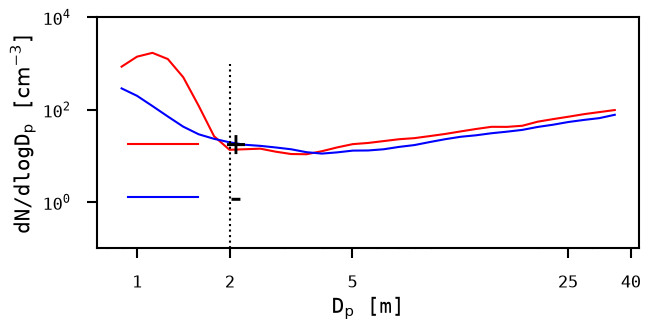

In [17]:
fig = plot_size_distribution(ds_nais_ions, diameters_ticks=[1,2, 5,25,40], average='mean')

In [18]:
def slice_by_time(ds, start_time, end_time):
    ds = ds.sel(time=slice(start_time, end_time))
    return ds

In [19]:
df_NPF_plusgrowth = pd.read_excel(loadpath_checked_start_end_times+'\\'+checked_start_end_times_filename, 
                                  index_col=0, parse_dates=True)
df_NPF_plusgrowth.index.name = 'event'

df_NPF_plusgrowth['start_date'] = df_NPF_plusgrowth['start_event'].dt.date
df_NPF_plusgrowth['start_date'] = df_NPF_plusgrowth['start_date'].astype(str)
df_NPF_plusgrowth['end_date'] = df_NPF_plusgrowth['end_event'].dt.date
df_NPF_plusgrowth['end_date'] = df_NPF_plusgrowth['end_date'].astype(str)

date='2022-04-18'
df_NPF_plusgrowth[df_NPF_plusgrowth['start_date'] == str(date)]

,start_event,end_event,event_class,comments,start_date,end_date
event,,,,,,
2022-04-18,2022-04-18 06:25:00,2022-04-19 03:00:00,Class II,NaN,2022-04-18,2022-04-19


## slice events: 

In [20]:
def save_ns_events(ds_nais, df_NPF_plusgrowth, id, savepath):
    savepath = savepath+'\\'+str(id)
    if_folder_doesnt_exist_create(savepath)
    print(savepath)
    ds_nais = ds_nais.loc[{'id':id}].copy()
    ds_nais = ds_nais.rename({'Dp': 'diameter'})
    for start_time, end_time in zip(list(df_NPF_plusgrowth.start_event.values), 
                                list(df_NPF_plusgrowth.end_event.values)):  
        ds_event = slice_by_time(ds_nais, start_time, end_time)
        name = str(pd.to_datetime(start_time).date()).replace('-','')
        print(name)
        ds_event.to_netcdf(savepath+'\\'+str(name)+'.nc')

In [21]:
def if_folder_doesnt_exist_create(directory):
    if not os.path.exists(directory):
        print("make directory: "+str(directory))
        os.makedirs(directory)

In [22]:
savepath_NPF_events_ions = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_ions'

save_events = True
if save_events == True:
    save_ns_events(ds_nais_ions, df_NPF_plusgrowth, id='pos_ions', savepath=savepath_NPF_events_ions)
    save_ns_events(ds_nais_ions, df_NPF_plusgrowth, id='neg_ions', savepath=savepath_NPF_events_ions)

C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_ions\pos_ions
20220417
20220418
20220421
20220423
20220424
20220428
20220429
NaT
20220502
20220503
20220504
20220505
20220516
20220517
20220519
20220520
20220522
20220530
20220602
20220605
20220613
20220614
20220617
20220624
20220625
20220702
20220703
20220709
20220715
20220717
20220718
20220719
20220722
20220723
20220724
20220725
20220731
20220803
20220812
20220814
20220815
20220816
20220826
20220827
20220828
20220830
NaT
20220914
20220915
20220917
20221010
20221015
20221021
20221022
20221125
20230512
20230516
NaT
20230518
20230519
20230524
20230525
20230526
20230527
20230529
20230531
20230602
NaT
20230605
20230606
20230610
20230612
20230616
20230627
NaT
20230630
20230702
20230703
20230704
20230707
20230710
20230712
20230715
20230716
20230717
20230719
20230722
20230723
20230728
20230803
NaT
20230807
20230808
20230809
20230810
20230822
20230823
20230828
20230830
20230903
20230907
20230911
20230

In [23]:
def remove_bad_data(ds, bad_data, select_time=False, select_time_and_diameter=True):
    """
    Set bad data to NaNs

    Parameters
    ----------
    ds : xarray.Dataset
        NAIS datafile
    bad_data : xarray.Dataset
        user-determined bad data boundaries using the `NaisChecker()`

    Returns
    -------
    xarray.Dataset
        Dataset with possible bad data set to `NaN`
    """

    neg_ion_bounds = [
        bad_data.neg_ion_time_left.values,
        bad_data.neg_ion_time_right.values,
        bad_data.neg_ion_diam_left.values,
        bad_data.neg_ion_diam_right.values]

    bad_data.close()

    ds_checked = ds.copy(deep=True)
    ds.close()
    
    print(ds_checked)
    neg_ions_checked = ds_checked.dndlDp.to_pandas()

    time_num = dts.date2num(ds.time.values)
    dp = ds.diameter.values
    
    for i in bad_data.neg_ion_roi_id.values:
        if select_time == True:
            neg_ions_checked.iloc[(time_num>=neg_ion_bounds[0][i])&(time_num<=neg_ion_bounds[1][i])] = np.nan
        if select_time_and_diameter == True:
            neg_ions_checked.iloc[
                (time_num>=neg_ion_bounds[0][i])&(time_num<=neg_ion_bounds[1][i]),
                (dp>=neg_ion_bounds[2][i])&(dp<=neg_ion_bounds[3][i])] = np.nan
    ds_checked.assign(neg_ions=(("time","diameter"),neg_ions_checked.values))
    return ds_checked


def clean_with_bounds(xr_event, date, 
                      infile_bounds,
                     add_extra_folder=True):
    if add_extra_folder == True:
        search_for_bounds = glob.glob(infile_bounds+'\\bounds\\*'+str(date).replace('-','')+'.nc')
        print(infile_bounds+'\\bounds\\*'+str(date).replace('-','')+'.nc')
        #print(search_for_bounds)
        
    if add_extra_folder == False:
        print(str(date[:4])+'_'+str(date[4:6]))
        search_for_bounds = glob.glob(infile_bounds+'\\*'+str(date[:4])+'_'+str(date[5:7])+'.nc')
        #print(infile_bounds+'\\*'+str(date[:4])+'_'+str(date[5:7])+'.nc')
        #print(search_for_bounds)

    if search_for_bounds:
        print("found bounds")
        search_for_bounds = xr.open_dataset(search_for_bounds[0])
        xr_event_removed = remove_bad_data(xr_event, search_for_bounds, select_time=False, select_time_and_diameter=True)
        del xr_event
    if not search_for_bounds:
        xr_event_removed = xr_event.copy()   
        del xr_event
    return xr_event_removed

In [24]:
def get_max(dn):
    max_dn_by_day = pd.DataFrame(columns=dn.columns, index=[str(dn.index[0].date())])
    for d in dn.columns:                
        max_dn_by_day.loc[str(dn.index[0].date()),d]=get_max_gaussian(dn.loc[:, d].dropna(), sigma=1)
    return max_dn_by_day

In [25]:
def get_xy_max_cleaned(max_dn_by_day, date):
    x_all = max_dn_by_day.loc[date, :].values
    y_all = max_dn_by_day.loc[date, :].index.values
    # clean up nan values
    y_all = y_all[~pd.isnull(x_all)]
    x_all = x_all[~pd.isnull(x_all)]
    return x_all, y_all
    
def plot_max(x_all, y_all, color="k", ax=None):
    ax.scatter(x_all, y_all, marker='o', color=color)
    return ax

In [26]:
def rate_of_change(dn, var=None):
    cols = dn.columns
    if var == None:
        dn['delta_N'] = dn.diff()
    if var != None:
        dn['delta_N'] = dn[var].diff()
    dn['datetime'] = dn.index
    dn['delta_T'] = dn['datetime'].diff()
    dn['delta_T'] = dn['delta_T'].dt.total_seconds()
    dn['rate_N_T'] = dn['delta_N']/dn['delta_T']
    return dn

def rate_change_time_df(dn):
    cols = dn.columns    
    datetime_max_list = []
    max_list = []
    diameters = []    
    df_max_rates = pd.DataFrame(columns=['diameter', 'datetime_max', 'max_rate'])
    for col in cols:
        dn_ = dn.loc[:, col].dropna().to_frame()
        dn_ = rate_of_change(dn_)
        gausian = gaussian_filter(dn_.loc[:, col].dropna(), sigma=1)    
        dn_['gausian'] = gausian    
        dn_ = rate_of_change(dn_, var='gausian')
        try:
            max_rate_gausian = np.nanmax(dn_['rate_N_T'].values)
            try:
                datetime_max = dn_[dn_['rate_N_T'] == max_rate_gausian].index.values[0]
            except:
                datetime_max = None
        except ValueError:
            max_rate_gausian = np.nan
            datetime_max = None            
        datetime_max_list.append(datetime_max)
        max_list.append(max_rate_gausian)
        diameters.append(col)        
    df_max_rates['datetime_max'] = datetime_max_list
    df_max_rates['max_rate'] = max_list
    df_max_rates['diameter'] = diameters    
    return df_max_rates

In [27]:
def removed_dup_index(df):
    df = df[~df.index.duplicated(keep='first')]
    return df

def quadratic_curve(x, a, b, c):
    return a*x**2 + b * x + c

def quadratic_curve_ab(x, a, b):
    return a*x**2 + b

def significant_figures(value, sf_num=3):
    sf = '{0:.'+str(sf_num)+'f}'
    value_sf = sf.format(value)    
    return value_sf

def solve_quadratic(a, b, c):
    """
    Solves the quadratic equation ax^2 + bx + c = 0.
    
    Parameters:
        a (float): Coefficient of x^2.
        b (float): Coefficient of x.
        c (float): Constant term.
    
    Returns:
        tuple: A tuple containing the roots of the quadratic equation.
    """
    discriminant = b**2 - 4*a*c
    
    if discriminant > 0:
        root1 = (-b + math.sqrt(discriminant)) / (2*a)
        root2 = (-b - math.sqrt(discriminant)) / (2*a)
        return root1, root2
    elif discriminant == 0:
        root = -b / (2*a)
        return root,
    else:
        real_part = -b / (2*a)
        imaginary_part = math.sqrt(abs(discriminant)) / (2*a)
        return complex(real_part, imaginary_part), complex(real_part, -imaginary_part)

def find_t_at_Dp(a_fit, b_fit, c_fit, Dp):
    a_fit = float(a_fit)
    b_fit = float(b_fit)
    c_fit = float(c_fit)
    if a_fit == 0:
        #print("a=0")
        if b_fit > 0:
            t = (np.log(Dp*10**(-9))-c_fit)/b_fit
            #print(t)
        if b_fit < 0:
            t = (c_fit-np.log(Dp*10**(-9)))/b_fit
    
    if a_fit > 0:
        a=a_fit
        b=b_fit
        c=c_fit-np.log(Dp*10**(-9))
        roots = solve_quadratic(a, b, c)
        try:
            t = [a for a in roots if 24>a][0] #24>a>0
        except:
            t = np.nan
        
    if a_fit < 0:
        a=a_fit
        b=b_fit
        c=c_fit-np.log(Dp*10**(-9))
        roots = solve_quadratic(a, b, c)
        try:
            t = [a for a in roots if 24>a][0] #24>a>0
        except:
            t = np.nan

    return t

def average_GR(Dp2, Dp1, t2, t1):
    average_gradient = (Dp2-Dp1)/(t2-t1)
    return average_gradient

def add_quadratic(df_datetime_diameter, ab=False, abc=True, starttime=None, ax=None):
    x_data = df_datetime_diameter[['hour']].values.flatten()  
    y_data = df_datetime_diameter['diameter'].values    
    x_fit = np.linspace(min(x_data), max(x_data), num=len(df_datetime_diameter.index)) #even linespace 
    if abc == True:     
        bounds = ((-np.inf, -np.inf, -np.inf), (0, np.inf, np.inf))
        params, covariance = curve_fit(quadratic_curve, x_data, np.log(y_data), 
                                      bounds=bounds,) # Perform the curve fitting
        a_fit, b_fit, c_fit = params # Get the fitted parameters
        y_fit = np.exp(quadratic_curve(x_fit, a_fit, b_fit, c_fit))

    if ab == True:   
        bounds = ((-np.inf, -np.inf), (0, np.inf))
        params, covariance = curve_fit(quadratic_curve_ab, x_data, np.log(y_data),
                                      bounds=bounds,) # Perform the curve fitting
        a_fit, b_fit = params # Get the fitted parameters
        y_fit = np.exp(quadratic_curve_ab(x_fit, a_fit, b_fit))

    ax2 = ax.twiny()

    a_fit = significant_figures(a_fit, sf_num=3)
    b_fit = significant_figures(b_fit, sf_num=3)    
    y_max = y_fit.max()

    if abc == True:
        c_fit = significant_figures(c_fit, sf_num=3)          
      
        str_t3='';str_t7='';str_t20=''   
        GR3_7=None;GR7_20=None
        string_GR3_7='';string_GR7_20=''
        
        if y_max >= 3*10**(-9):
            t3 = find_t_at_Dp(a_fit, b_fit, c_fit, Dp=3)
            str_t3 = 't$_{3nm}$ = '+str(significant_figures(t3, sf_num=3))
            
        if y_max >= 7*10**(-9):
            t7 = find_t_at_Dp(a_fit, b_fit, c_fit, Dp=7)
            str_t7 = 't$_{7nm}$ = '+str(significant_figures(t7, sf_num=3))
            GR3_7 = average_GR(7, 3, t7, t3)
            string_GR3_7 = 'GR$_{3-7nm}$ = '+str(significant_figures(GR3_7, sf_num=3))
            
        if y_max >= 20*10**(-9):
            t20 = find_t_at_Dp(a_fit, b_fit, c_fit, Dp=20)  
            str_t20 = 't$_{20nm}$ = '+str(significant_figures(t20, sf_num=3))
            GR7_20 = average_GR(20, 7, t20, t7)
            string_GR7_20 = 'GR$_{7-20nm}$ = '+str(significant_figures(GR7_20, sf_num=3))
        
        times = str_t3+' hr, '+str_t7+' hr, '+str_t20+' hr '        

        y_index = list(y_fit).index(y_fit.max())
        x_fit = x_fit[:y_index]
        y_fit = y_fit[:y_index]
        ax2.plot(x_fit, 
                 y_fit, 
         label='log(D$_{p}$) = '+str(a_fit)+'t$^{2}$ + '+str(b_fit)+'t + '+str(c_fit)+'\ntimes after start time: \n'+str(times)+'\n'+str(string_GR3_7)+'\n'+str(string_GR7_20),
                 color='b')
        
    if ab == True:
        ax2.plot(x_fit, y_fit, label='log(D$_{p}$) = '+str(a_fit)+'t$^{2}$ + '+str(b_fit), color='b')        

    #ax2.set_xlim(0,16.750000)
    hour_start = df_datetime_diameter['datetime'][0].time().hour
    minute_start = df_datetime_diameter['datetime'][0].time().minute
    hour_end = df_datetime_diameter['datetime'].iloc[-1].time().hour
    minute_end = df_datetime_diameter['datetime'].iloc[-1].time().minute    
    end_decimal = df_datetime_diameter.hour.iloc[-1]
    #ax2.set_xlim(-(hour_start+(minute_start/60)),end_decimal+(24-hour_end)-minute_end/60)
    ax2.legend(loc=1, frameon=False)
    ax2.set_xticks([])
    return ax


def make_GR_plot(df_datetime_diameter, starttime, add_quad=True, ab=False, abc=True, marker='o', c='r', 
                 c_ols='red', c_hourly='orange', ax=None):
    single_plot = False    
    if ax == None:
        fig, ax = plt.subplots(figsize=(10, 5))
        single_plot = True           
    try:
        df_datetime_diameter = df_datetime_diameter[df_datetime_diameter.index > starttime].copy()        
    except:
        pass    
    X = df_datetime_diameter[['hour']]  
    y = df_datetime_diameter['diameter']         
    model = LinearRegression()
    model.fit(X, y)    
    y_pred = model.predict(X)
    ax.scatter(df_datetime_diameter['datetime'].values, y, label='GR data', color='k', marker='o')    
    ax.plot(df_datetime_diameter['datetime'].values, y_pred, 
            label='GR (OLS): '+str(np.round(model.coef_[0]*10**9, 2))+' [nm/hr]\nfrom: '+str(starttime), color=c_ols)
    ax.set_ylabel('Diameters [nm]')   
    ax.legend(loc=2, frameon=False)       
    if add_quad == True:
        add_quadratic(df_datetime_diameter, ab=ab, abc=abc, starttime=starttime, ax=ax)
    if add_quad == False:
        pass 
    if single_plot == True:
        return fig
    if single_plot == False:
        return ax

In [28]:
def GR_equation(df_datetime_diameter, starttime, add_quad=True, ab=False, abc=True):          
    try:
        df_datetime_diameter = df_datetime_diameter[df_datetime_diameter.index > starttime].copy()        
    except:
        pass    
    X = df_datetime_diameter[['hour']]  
    y = df_datetime_diameter['diameter'] 
    datetimes = df_datetime_diameter['datetime'].values        
    model = LinearRegression()
    model.fit(X, y)    
    y_pred = model.predict(X)
    slope = model.coef_[0]           
    if add_quad == True:
        add_quadratic(df_datetime_diameter, ab=ab, abc=abc, starttime=starttime, ax=ax)
    if add_quad == False:
        pass 
    return slope, y_pred, datetimes

In [29]:
def get_hours_multiday(df):
    df['ordinal'] = df['datetime'].apply(lambda x: x.toordinal())    
    first_day = df['ordinal'].iloc[0]
    df['hour_ordinal'] = (df['ordinal']-first_day)*24
    df['hour_in_day'] = df['datetime'].dt.hour
    df['minute_in_day'] = df['datetime'].dt.minute
    df['hour'] = df['hour_ordinal']+df['hour_in_day']+(df['minute_in_day']/60)
    return df

def add_hour_rate(df_rate, starttime):
    df_rate = df_rate.copy()
    df_rate = df_rate.set_index('datetime_max')
    df_rate['datetime'] = df_rate.index.copy()
    df_rate.index = pd.to_datetime(df_rate.index)
    df_rate = df_rate.sort_index()
    df_rate = df_rate.dropna(subset=['max_rate'], how='any')
    if len(df_rate) > 0:
        df_rate = df_rate[df_rate.index > pd.to_datetime(starttime)]
        df_rate = get_hours_multiday(df_rate)
    df_rate = df_rate.reset_index()
    return df_rate

In [30]:
def slice_dim_xr(ds, min_dim=None, max_dim = 2e-8):
    return ds.loc[{'diameter':slice(min_dim, max_dim)}]

In [31]:
def spectral_plot(xr_nais, var, title, x='time', fs_label=20, xlabel='Datetime', log_colour_scale=True, 
                  add_axis_labels=True,
                  add_colourbar_labels=False, vmin=10**(-1), vmax=10**5, diameters_ticks=None,
                  cbar_label=r'dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', 
                  ylabel='D$_{\\mathrm{p}}$ [m]', cmap='jet', xmin=None, xmax=None, 
                  remove_xticks=False, alpha=1, ymin=None, ymax=None, DateFormat='%m-%y', ax=None): #magma
    single_plot = False
    if ax == None:
        fig, ax = plt.subplots(figsize=(25,5))
        single_plot = True
        
    if log_colour_scale == True:
        xr_nais[var] = xr.where(xr_nais[var]==0, 10**(-100), xr_nais[var])    
        im = xr_nais[var].plot(x=x, yscale='log', norm=LogNorm(vmin=vmin,vmax=vmax), cmap=cmap, 
                                        add_colorbar=False, alpha=alpha, ax=ax)
    if log_colour_scale == False:
        im = xr_nais[var].plot(x=x, yscale='log', vmin=vmin, vmax=vmax, cmap=cmap, 
                                        add_colorbar=False, alpha=alpha, ax=ax)    
    if add_axis_labels == True:
        ax.set_ylabel(ylabel, fontsize=fs_label)
        ax.set_xlabel(xlabel, fontsize=fs_label)
        ax.set_title(title, fontsize=15, loc='left')
    
    thickax(ax, fontsize=fs_label)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    
    if remove_xticks == True:
        ax.set_xticklabels([])
       
    if add_colourbar_labels == True: 
        cb = plt.colorbar(im, orientation="vertical")
        cb.set_label(label=cbar_label, size=fs_label)
        cb.ax.tick_params(labelsize=fs_label)

    if diameters_ticks is not None:       
        yticks = [x*10**(-9) for x in diameters_ticks]
        #yticks = [x for x in diameters_ticks]
        print(yticks)
        ax.set_yticks(yticks)
        print(diameters_ticks)
        ax.set_yticklabels(diameters_ticks, fontsize=10)

    if remove_xticks == False:
        ax.xaxis.set_major_formatter(md.DateFormatter(DateFormat))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
        plt.xticks(fontsize=14, rotation=0)

    if remove_xticks == True:
        ax.set_xticks([])
        ax.set_xticklabels([])        

    if single_plot == True:
        plt.show()
        return fig
    if single_plot == False:
        return ax

def thickax(ax, fontsize=12):
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.5)
    plt.rc('axes', linewidth=1.5)    
    ax = plt.gca()
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    ax.tick_params(direction='out', length=7, width=1.5, pad=12, bottom=True, top=False, left=True, right=False)
	

In [32]:
date='2022-05-02'
name = date.replace('-','')

id = 'pos_ions'
NPF_events_ions_loadpath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_ions'
NPF_events_ions_loadpath = NPF_events_ions_loadpath+'\\'+str(id)
ds_event = xr.open_dataset(NPF_events_ions_loadpath+'\\'+str(name)+'.nc')
print(NPF_events_ions_loadpath+'\\'+str(name)+'.nc')

infile_bounds=r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS'

ds_event = slice_dim_xr(ds_event, min_dim=2e-9, max_dim =4e-9)
ds_event_cleaned = clean_with_bounds(ds_event, date, infile_bounds, add_extra_folder=True)

C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_ions\pos_ions\20220502.nc
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20220502.nc
found bounds
<xarray.Dataset> Size: 5kB
Dimensions:   (time: 86, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 688B 2022-05-02T05:45:00 ... 2022-05-03T0...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 4kB ...


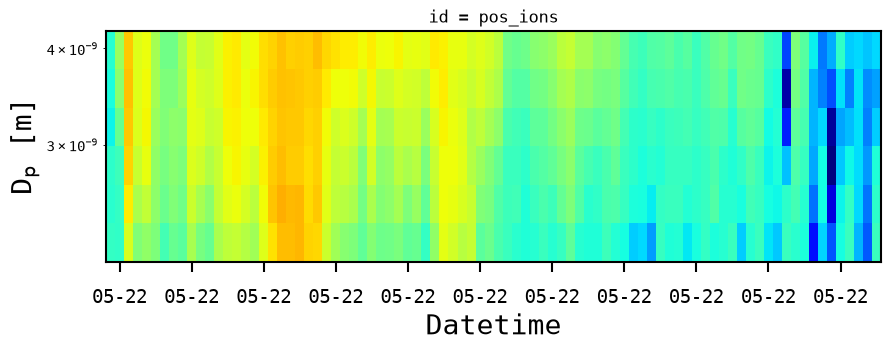

In [33]:
fig, ax = plt.subplots(figsize=(10, 3))
spectral_plot(ds_event_cleaned, var='dndlDp', x='time', title='', ax=ax)
spectral_plot(ds_event, var='dndlDp', x='time', title='', alpha=.2, ax=ax)
plt.show()

In [34]:
def get_clean_ds_event(loadpath_NPF_events_ions, infile_bounds, date='2022-05-02', id = 'pos_ions'):
    name = date.replace('-','')
    loadpath_NPF_events_ions = loadpath_NPF_events_ions+'\\'+str(id) #r'C:\Users\DominicHeslinRees\NAIS_work\select_bonds\NPF_events_ions'
    ds_event = xr.open_dataset(loadpath_NPF_events_ions+'\\'+str(name)+'.nc')
    ds_event = slice_dim_xr(ds_event, min_dim=2e-9, max_dim=4e-9)
    #infile_bounds=r'C:\Users\DominicHeslinRees\NAIS_work\select_bonds\NPF_events_DMPS_NAIS'
    ds_event_cleaned = clean_with_bounds(ds_event, date, infile_bounds=infile_bounds,
                        add_extra_folder=True)
    return ds_event_cleaned

C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20220502.nc
found bounds
<xarray.Dataset> Size: 5kB
Dimensions:   (time: 86, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 688B 2022-05-02T05:45:00 ... 2022-05-03T0...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 4kB ...


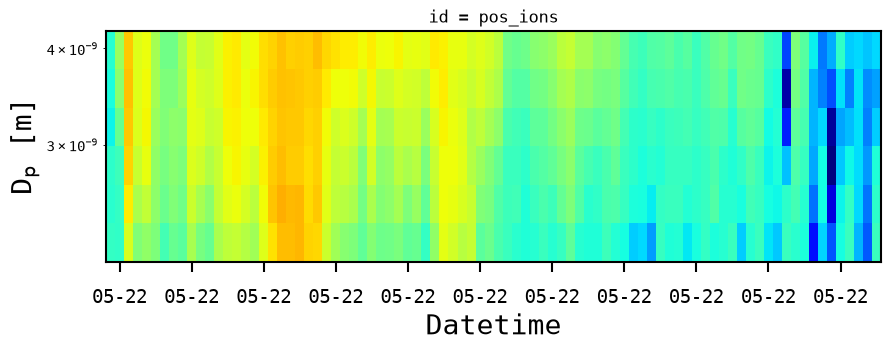

In [35]:
NPF_events_ions_loadpath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_ions'
infile_bounds=r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS'

ds_event_cleaned_pos_ions = get_clean_ds_event(NPF_events_ions_loadpath, infile_bounds,
                                               date='2022-05-02', id = 'pos_ions')

fig, ax = plt.subplots(figsize=(10, 3))
spectral_plot(ds_event_cleaned_pos_ions, var='dndlDp', x='time', title='', ax=ax)
plt.show()

C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20220502.nc
found bounds
<xarray.Dataset> Size: 5kB
Dimensions:   (time: 86, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 688B 2022-05-02T05:45:00 ... 2022-05-03T0...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 4kB ...


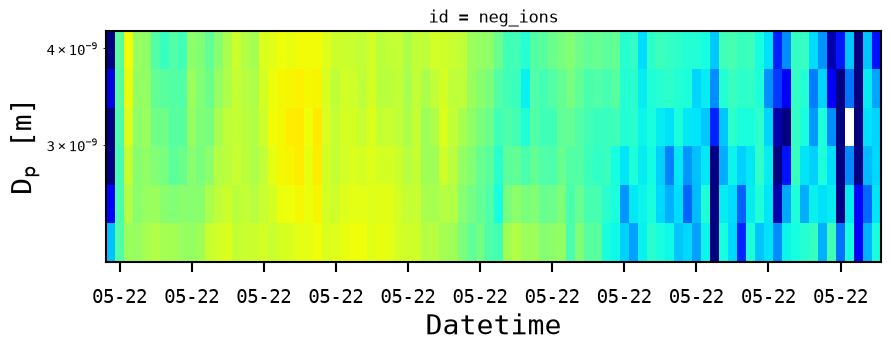

In [36]:
ds_event_cleaned_neg_ions = get_clean_ds_event(NPF_events_ions_loadpath, infile_bounds,
                                               date='2022-05-02', id = 'neg_ions')

fig, ax = plt.subplots(figsize=(10, 3))
spectral_plot(ds_event_cleaned_neg_ions, var='dndlDp', x='time', title='', ax=ax)
plt.show()

C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20220502.nc
found bounds
<xarray.Dataset> Size: 5kB
Dimensions:   (time: 86, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 688B 2022-05-02T05:45:00 ... 2022-05-03T0...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 4kB ...


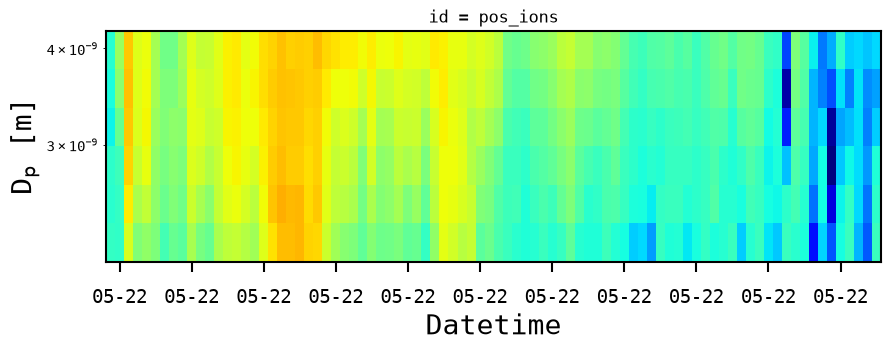

In [37]:
ds_event_cleaned_pos_ions = get_clean_ds_event(NPF_events_ions_loadpath, infile_bounds,
                                               date='2022-05-02', id = 'pos_ions')

fig, ax = plt.subplots(figsize=(10, 3))
spectral_plot(ds_event_cleaned_pos_ions, var='dndlDp', x='time', title='', ax=ax)
plt.show()

In [38]:
n_neg_ions = get_n(ds_event_cleaned_neg_ions, min_size=2, max_size=4)
n_pos_ions = get_n(ds_event_cleaned_pos_ions, min_size=2, max_size=4)

Bins: [2.24, 2.51, 2.82, 3.16, 3.55, 3.98]
Bins: [2.24, 2.51, 2.82, 3.16, 3.55, 3.98]


0.5748104688515374


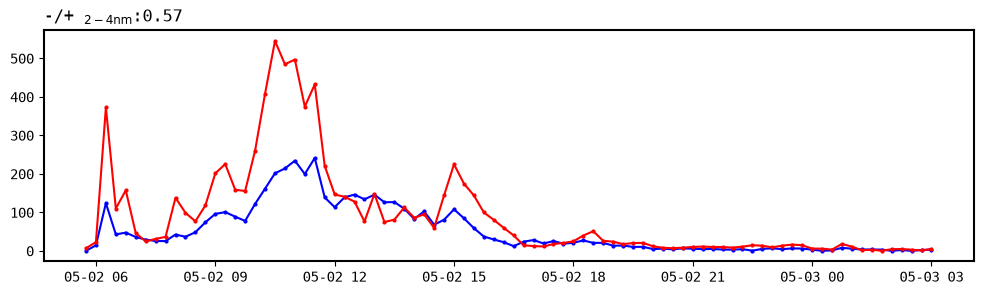

In [39]:
fig, ax = plt.subplots(figsize=(12,3))
y = n_neg_ions['dndlDp'].values
x = n_neg_ions['time'].values      
ax.plot(x, y, 'o-', ms=2, c='b')  
y = n_pos_ions['dndlDp'].values
x = n_pos_ions['time'].values      
ax.plot(x, y, 'o-', ms=2, c='r')  
neg_pos_ratio = float(n_neg_ions['dndlDp'].sum()/n_pos_ions['dndlDp'].sum())
print(neg_pos_ratio)

ax.set_title('-/+ $_{2-4\\mathrm{nm}}$:'+str(np.round(neg_pos_ratio, 2)), loc='left')

plt.show()

In [40]:
neg_pos_ratio = float(n_neg_ions['dndlDp'].sum()/n_pos_ions['dndlDp'].sum())

In [41]:
def get_digits(string_with_digits):
    digit = re.findall(r'\d+', string_with_digits) 
    print("digits: "+str(digit))
    return digit
    
def get_event_files(event_days, files, digit_order=1):
    files_list = []
    digit_files = [get_digits(x)[digit_order] for x in files]
    print(digit_files)
    for event in event_days:
        string_event = str(event)[:10].replace('-','')      
        index = digit_files.index(string_event)
        file = files[index]
        files_list.append(file)
    return files_list

In [42]:
class_path = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\DalMaso_classification'
ZEP_class = pd.read_csv(class_path+'\ZEP_class_DalMaso.txt', index_col=0, 
                        parse_dates=True)

df_classIa = ZEP_class[ZEP_class['Class Ia'].notnull()]
df_classIb = ZEP_class[ZEP_class['Class Ib'].notnull()]
df_classII = ZEP_class[ZEP_class['Class II'].notnull()]

print("total number: ")
print(len(df_classIa)+len(df_classIb)+len(df_classII))

df_classUndefined = ZEP_class[ZEP_class['Undefined'].notnull()]
df_classNonE = ZEP_class[ZEP_class['Non-event'].notnull()]

dict_name_to_df = {}
dict_name_to_df['Class Ia'] = df_classIa
dict_name_to_df['Class Ib'] = df_classIb
dict_name_to_df['Class II'] = df_classII
dict_name_to_df['Undefined'] = df_classUndefined 
dict_name_to_df['Non-event'] = df_classNonE

event_days = list(df_classIa.index.unique())+list(df_classIb.index.unique())+list(df_classII.index.unique())

event_days = sorted(event_days)
event_days = [pd.to_datetime(str(x)) for x in event_days]

ZEP_processed_data = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\ZEP_processed_files'
files = glob.glob(ZEP_processed_data+'\\*.nc')

total number: 
155


<>:2: SyntaxWarning: "\Z" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\Z"? A raw string is also an option.
<>:2: SyntaxWarning: "\Z" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\Z"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_22268\3976735299.py:2: SyntaxWarning: "\Z" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\Z"? A raw string is also an option.
  ZEP_class = pd.read_csv(class_path+'\ZEP_class_DalMaso.txt', index_col=0,


In [43]:
date_ratios = {}
event_neg_ions = {}
event_pos_ions = {}

for event_day in event_days:
    date = str(event_day.date())    
    try:
        ds_event_cleaned_neg_ions = get_clean_ds_event(NPF_events_ions_loadpath, infile_bounds, 
                                                    date=date, id = 'neg_ions')
        ds_event_cleaned_pos_ions = get_clean_ds_event(NPF_events_ions_loadpath, infile_bounds,
                                                    date=date, id = 'pos_ions')

        n_neg_ions = get_n(ds_event_cleaned_neg_ions, min_size=2, max_size=4)/neg_pos_ratio_CF
        n_pos_ions = get_n(ds_event_cleaned_pos_ions, min_size=2, max_size=4)
        neg_pos_ratio = float(n_neg_ions['dndlDp'].sum()/n_pos_ions['dndlDp'].sum())
            
        date_ratios[date] = neg_pos_ratio
        event_neg_ions[date] = float(n_neg_ions['dndlDp'].sum()) #day sum but we wanna do like for like comparsions
        event_pos_ions[date] = float(n_pos_ions['dndlDp'].sum())
        
    except:
        print("error")

C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20220418.nc
found bounds
<xarray.Dataset> Size: 5kB
Dimensions:   (time: 83, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 664B 2022-04-18T06:30:00 ... 2022-04-19T0...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 4kB ...
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20220418.nc
found bounds
<xarray.Dataset> Size: 5kB
Dimensions:   (time: 83, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 664B 2022-04-18T06:30:00 ... 2022-04-19T0...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 4kB ...
Bins: [2.24, 2.51, 2.82, 3.16, 3.55, 3.98]
Bins: [2.24, 2.51, 2.82, 3.

In [44]:
df_event_neg_ions = pd.DataFrame(event_neg_ions.items(), columns=['date', 'neg_ions_2_4nm'])
df_event_neg_ions = df_event_neg_ions.set_index('date')
df_event_neg_ions.index = pd.to_datetime(df_event_neg_ions.index)

df_event_pos_ions = pd.DataFrame(event_pos_ions.items(), columns=['date', 'pos_ions_2_4nm'])
df_event_pos_ions = df_event_pos_ions.set_index('date')
df_event_pos_ions.index = pd.to_datetime(df_event_pos_ions.index)

In [45]:
df_ratios = pd.DataFrame(date_ratios.items(), columns=['date', 'ratio_neg_pos_2_4nm'])
df_ratios = df_ratios.set_index('date')
df_ratios.index = pd.to_datetime(df_ratios.index)

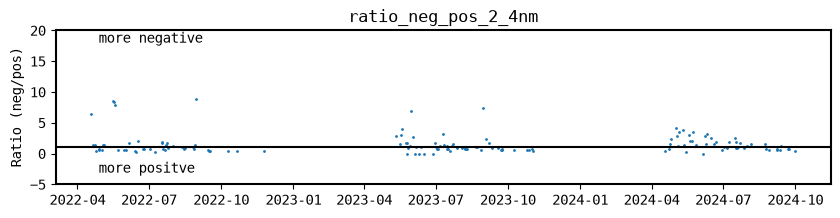

In [46]:
fig, ax = plt.subplots(figsize=(10, 2))
ax.plot(df_ratios.index, df_ratios['ratio_neg_pos_2_4nm'].values, 'o', ms=1)
ax.axhline(y=1, c='k')
ax.set_ylim(-5, 20)
ax.set_ylabel('Ratio (neg/pos)')
ax.text(x=pd.to_datetime('2022-04-28'), y=18, s='more negative')
ax.text(x=pd.to_datetime('2022-04-28'), y=-3.1, s='more positve')
ax.set_title('ratio_neg_pos_2_4nm')
plt.show()

In [47]:
df_ratios['month'] = df_ratios.index.month

def q50(x):
    return x.quantile(0.5)
def q25(x):
    return x.quantile(0.25)
def q75(x):
    return x.quantile(0.75)

df_ratios_M = df_ratios.groupby('month').agg({'ratio_neg_pos_2_4nm': [q50, q25, q75, 'mean', 'count']})
df_ratios_M.columns = ['q50', 'q25', 'q75', 'mean', 'count']

In [48]:
def make_annual_ratio_plot(df_ratios_M):
        fig, ax = plt.subplots(figsize=(7, 3))
        ax.plot(df_ratios_M.index, df_ratios_M['mean'].values, 'x', ms=5, c='k', ls=':')

        cmap = plt.cm.RdBu  # Choose a diverging colormap
        norm = mcolors.TwoSlopeNorm(vmin=.5, vcenter=1,
                                vmax=2) 
        sm = ax.scatter(df_ratios_M.index, df_ratios_M['q50'].values, c=df_ratios_M['q50'].values, 
                s=50, ls=':', cmap=cmap, norm=norm)

        ax.plot(df_ratios_M.index, df_ratios_M['q50'].values, mec='k', 
                markeredgewidth=5, mfc='None', c='k', alpha=.3)

        x = df_ratios_M.index
        y1 = df_ratios_M['q25'].values
        y2 = df_ratios_M['q75'].values

        ax.fill_between(x, y1, y2, where=y2 >= y1,
                        facecolor='gray', interpolate=True, alpha=.3)

        counts = df_ratios_M['count'].values
        months = df_ratios_M.index

        for count, month in zip(counts, months):
                y = float(df_ratios_M[df_ratios_M.index == month]['mean'].values[0])+.5
                plt.text(month, y, str(count), ha='left', va='top') #, transform=ax.transAxes)

        ax.axhline(y=1, c='k', alpha=.5, ls=':')
        ax.set_ylim(-0.5, 6)
        ax.set_ylabel('N$^{-}$$_{2-4\mathrm{nm}}$/N$^{+}$$_{2-4\mathrm{nm}}$ [-]', fontsize=15) 
        tick_positions = list(np.arange(1, 13, 1))
        tick_labels = ['J','F','M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
        ax.text(x=9, y=0, s='more positve', c='r')
        ax.text(x=9, y=3.7, s='more negative', c='b')

        cax = fig.add_axes([0.27, 0.8, 0.5, 0.05])
        fig.colorbar(sm, cax=cax, orientation='horizontal')

        plt.show()
        return fig

<>:30: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:30: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_22268\1487245058.py:30: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_ylabel('N$^{-}$$_{2-4\mathrm{nm}}$/N$^{+}$$_{2-4\mathrm{nm}}$ [-]', fontsize=15)


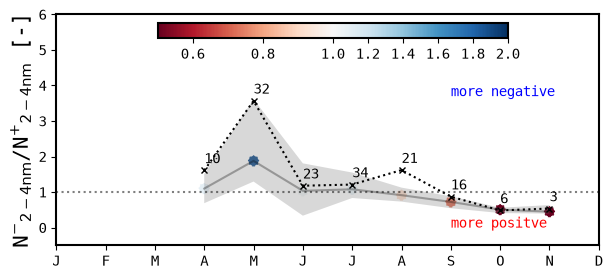

In [49]:
fig = make_annual_ratio_plot(df_ratios_M)

In [50]:
# dataframe for ratios: 
savepath_airion_rations = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\air_ion_ratios'
df_ratios.to_csv(savepath_airion_rations+'\\airion_ratios.dat', index=True)

# all ratio data:

In [51]:
resolution = '5min'
nais_cleaned_loadpath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\resampled\resampled_removed_snow_clouds_bad_charged'
XR_resampled = xr.open_dataset(nais_cleaned_loadpath+'\\'+str(resolution)+'_removed_snow_clouds_bad_charged.nc')
polarity='neg';
mode='ions'

nanoranking_save_folder=r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\Nano_ranking'

########## REGRID AND INTERPOLATE 5 MINUTE NAIS DATA TO 15 MINUTES ####################################################################
id='neg_ions'
ds_nais_neg = rename_resample_xr(XR_resampled, polarity='neg', mode='ions', 
                             resolution='15min', average='median')
ds_nais_neg = regrid_ds(ds_nais_neg)
ds_nais_neg =  interpolate_ds(ds_nais_neg, minutes=15)
ds_nais_neg = ds_nais_neg.expand_dims({'id':[id]})
ds_nais_neg = ds_nais_neg.drop_vars('lDp')

id='pos_ions'
ds_nais_pos = rename_resample_xr(XR_resampled, polarity='pos', mode='ions', 
                             resolution='15min', average='median')
ds_nais_pos = regrid_ds(ds_nais_pos)
ds_nais_pos =  interpolate_ds(ds_nais_pos, minutes=15)
ds_nais_pos = ds_nais_pos.expand_dims({'id':[id]})
ds_nais_pos = ds_nais_pos.drop_vars('lDp')

ds_nais_ions = (xr.concat([ds_nais_neg, ds_nais_pos], dim='id'))
ds_nais_ions = ds_nais_ions.loc[{'time':slice('2022-04-17','2024-10-04')}]

ds_neg_ions_events = n_neg_ions.drop_vars('id')

original dims: ['time', 'Dp']
original dims: ['time', 'Dp']


In [52]:
ds_neg_ion_2_4_sum =get_n(ds_nais_ions.loc[{'id':'neg_ions'}], min_size=2, max_size=4, diameter_var='Dp',
          var='dndlDp').drop_vars('id')
ds_pos_ion_2_4_sum =get_n(ds_nais_ions.loc[{'id':'pos_ions'}], min_size=2, max_size=4, diameter_var='Dp',
          var='dndlDp').drop_vars('id')

xr_ratio = ds_neg_ion_2_4_sum/ds_pos_ion_2_4_sum
xr_ratio = xr_ratio.rename_vars({'dndlDp':'ratio'})
xr_ratio_D = xr_ratio.resample({'time':'D'}).median()

xr_total = ds_neg_ion_2_4_sum+ds_pos_ion_2_4_sum
xr_neg_by_total = ds_neg_ions_events/(ds_neg_ion_2_4_sum+ds_pos_ion_2_4_sum)
xr_neg_by_total = xr_neg_by_total.rename_vars({'dndlDp':'neg_by_total'})

Bins: [0.5, 0.56, 0.63, 0.71, 0.79, 0.89, 1.0, 1.12, 1.26, 1.41, 1.58, 1.78, 2.0, 2.24, 2.51, 2.82, 3.16, 3.55, 3.98, 4.47, 5.01, 5.62, 6.31, 7.08, 7.94, 8.91, 10.0, 11.22, 12.59, 14.13, 15.85, 17.78, 19.95, 22.39, 25.12, 28.18, 31.62, 35.48, 39.81, 44.67]
Bins: [0.5, 0.56, 0.63, 0.71, 0.79, 0.89, 1.0, 1.12, 1.26, 1.41, 1.58, 1.78, 2.0, 2.24, 2.51, 2.82, 3.16, 3.55, 3.98, 4.47, 5.01, 5.62, 6.31, 7.08, 7.94, 8.91, 10.0, 11.22, 12.59, 14.13, 15.85, 17.78, 19.95, 22.39, 25.12, 28.18, 31.62, 35.48, 39.81, 44.67]


In [53]:
def ratio_neg_pos_timeseries(xr_ratio, xr_ratio_D):
    fig, ax = plt.subplots(figsize=(10, 2))
    ax.plot(xr_ratio['time'].values, xr_ratio['ratio'].values, 'o', ms=1, c='k', alpha=.5)
    ax.plot(xr_ratio_D['time'].values, xr_ratio_D['ratio'].values, 'o-', ms=1)
    ax.axhline(y=1, c='k')
    ax.set_ylim(-5, 20)
    ax.set_ylabel('Ratio (neg/pos)')
    ax.text(x=pd.to_datetime('2022-04-28'), y=18, s='more negative')
    ax.text(x=pd.to_datetime('2022-04-28'), y=-3.1, s='more positve')
    ax.set_title('ratio_neg_pos_2_4nm')
    plt.show()
    return fig

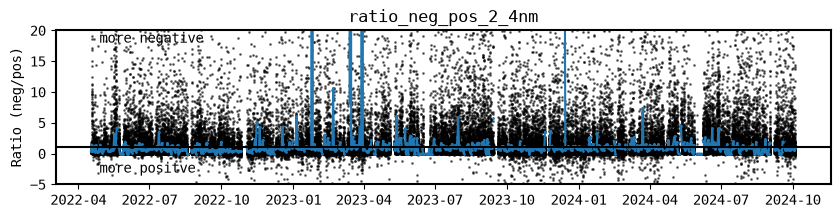

In [54]:
fig = ratio_neg_pos_timeseries(xr_ratio, xr_ratio_D)

In [55]:
df_ratio = xr_ratio.to_dataframe()
df_ratio['month'] = df_ratio.index.month
df_ratio_M = df_ratio.groupby('month').agg({'ratio': [q50, q25, q75, 'mean', 'count']})
df_ratio_M.columns = ['q50', 'q25', 'q75', 'mean', 'count']

In [56]:
def annual_ratio_plot(df):
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(df.index, df['mean'].values, 'x', ms=5, c='k', ls=':')
    cmap = plt.cm.RdBu  # Choose a diverging colormap
    norm = mcolors.TwoSlopeNorm(vmin=.5, vcenter=1,
                                vmax=2) 
    sm = ax.scatter(df.index, df['q50'].values, c=df['q50'].values, 
            s=50, ls=':', cmap=cmap, norm=norm)
    ax.plot(df.index, df['q50'].values, mec='k', 
            markeredgewidth=5, mfc='None', c='k', alpha=.3)
    x = df.index
    y1 = df['q25'].values
    y2 = df['q75'].values
    ax.fill_between(x, y1, y2, where=y2 >= y1,
                    facecolor='gray', interpolate=True, alpha=.3)
    counts = df['count'].values
    months = df.index
    for count, month in zip(counts, months):
        y = float(df[df.index == month]['mean'].values[0])+.5
        plt.text(month, y, str(count), ha='left', va='top')

    ax.axhline(y=1, c='k', alpha=.5, ls=':')
    ax.set_ylim(-0.5, 6)
    ax.set_ylabel('N$^{-}$$_{2-4\\mathrm{nm}}$/N$^{+}$$_{2-4\\mathrm{nm}}$ [-]', fontsize=15) 
    tick_positions = list(np.arange(1, 13, 1))
    print(tick_positions)
    tick_labels = ['J','F','M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.text(x=9, y=0, s='more positve', c='r')
    ax.text(x=9, y=3.7, s='more negative', c='b')

    cax = fig.add_axes([0.27, 0.8, 0.5, 0.05])
    fig.colorbar(sm, cax=cax, orientation='horizontal')
    plt.show()
    return fig

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


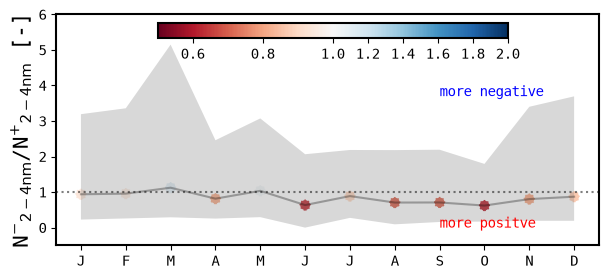

In [57]:
fig = annual_ratio_plot(df_ratio_M)

In [58]:
df_ratios = pd.DataFrame(date_ratios.items(), columns=['date', 'ratio_neg_pos_2_4nm'])
df_ratios = df_ratios.set_index('date')
df_ratios.index = pd.to_datetime(df_ratios.index)

In [59]:
date_neg_total_ratios = {}
date_pos_total_ratios = {}

DFs=[]
for event_day in event_days:
    date = str(event_day.date())    
    try:
        ds_event_cleaned_neg_ions = get_clean_ds_event(NPF_events_ions_loadpath, infile_bounds, 
                                                            date=date, id = 'neg_ions')
        ds_event_cleaned_pos_ions = get_clean_ds_event(NPF_events_ions_loadpath, infile_bounds,
                                                            date=date, id = 'pos_ions')        
        n_neg_ions = get_n(ds_event_cleaned_neg_ions, min_size=2, max_size=4) #neg_pos_ratio_CF
        n_pos_ions = get_n(ds_event_cleaned_pos_ions, min_size=2, max_size=4)
        df_neg_ions = n_neg_ions.drop('id').to_dataframe().rename(columns={'dndlDp':'neg_ions_2_4nm'})
        df_pos_ions = n_pos_ions.drop('id').to_dataframe().rename(columns={'dndlDp':'pos_ions_2_4nm'})
        df_neg_pos_ions = df_neg_ions.merge(df_pos_ions, left_index=True, right_index=True)
        DFs.append(df_neg_pos_ions)       
    except:
        print("error")

C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20220418.nc
found bounds
<xarray.Dataset> Size: 5kB
Dimensions:   (time: 83, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 664B 2022-04-18T06:30:00 ... 2022-04-19T0...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 4kB ...
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20220418.nc
found bounds
<xarray.Dataset> Size: 5kB
Dimensions:   (time: 83, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 664B 2022-04-18T06:30:00 ... 2022-04-19T0...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 4kB ...
Bins: [2.24, 2.51, 2.82, 3.16, 3.55, 3.98]
Bins: [2.24, 2.51, 2.82, 3.

C:\Users\Dell\AppData\Local\Temp\ipykernel_22268\58312760.py:14: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  df_neg_ions = n_neg_ions.drop('id').to_dataframe().rename(columns={'dndlDp':'neg_ions_2_4nm'})
C:\Users\Dell\AppData\Local\Temp\ipykernel_22268\58312760.py:15: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  df_pos_ions = n_pos_ions.drop('id').to_dataframe().rename(columns={'dndlDp':'pos_ions_2_4nm'})


C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20220421.nc
found bounds
<xarray.Dataset> Size: 3kB
Dimensions:   (time: 44, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 352B 2022-04-21T05:45:00 ... 2022-04-21T1...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 2kB ...
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20220421.nc
found bounds
<xarray.Dataset> Size: 3kB
Dimensions:   (time: 44, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 352B 2022-04-21T05:45:00 ... 2022-04-21T1...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 2kB ...
Bins: [2.24, 2.51, 2.82, 3.16, 3.55, 3.98]
Bins: [2.24, 2.51, 2.82, 3.

C:\Users\Dell\AppData\Local\Temp\ipykernel_22268\58312760.py:14: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  df_neg_ions = n_neg_ions.drop('id').to_dataframe().rename(columns={'dndlDp':'neg_ions_2_4nm'})
C:\Users\Dell\AppData\Local\Temp\ipykernel_22268\58312760.py:15: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  df_pos_ions = n_pos_ions.drop('id').to_dataframe().rename(columns={'dndlDp':'pos_ions_2_4nm'})


C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20220423.nc
found bounds
<xarray.Dataset> Size: 3kB
Dimensions:   (time: 61, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 488B 2022-04-23T06:00:00 ... 2022-04-23T2...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 3kB ...
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20220423.nc
found bounds
<xarray.Dataset> Size: 3kB
Dimensions:   (time: 61, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 488B 2022-04-23T06:00:00 ... 2022-04-23T2...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 3kB ...
Bins: [2.24, 2.51, 2.82, 3.16, 3.55, 3.98]
Bins: [2.24, 2.51, 2.82, 3.

...

C:\Users\Dell\AppData\Local\Temp\ipykernel_22268\58312760.py:14: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  df_neg_ions = n_neg_ions.drop('id').to_dataframe().rename(columns={'dndlDp':'neg_ions_2_4nm'})
C:\Users\Dell\AppData\Local\Temp\ipykernel_22268\58312760.py:15: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  df_pos_ions = n_pos_ions.drop('id').to_dataframe().rename(columns={'dndlDp':'pos_ions_2_4nm'})


<xarray.Dataset> Size: 4kB
Dimensions:   (time: 65, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 520B 2024-09-23T07:45:00 ... 2024-09-23T2...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 3kB ...
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20240923.nc
found bounds
<xarray.Dataset> Size: 4kB
Dimensions:   (time: 65, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 520B 2024-09-23T07:45:00 ... 2024-09-23T2...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 3kB ...
Bins: [2.24, 2.51, 2.82, 3.16, 3.55, 3.98]
Bins: [2.24, 2.51, 2.82, 3.16, 3.55, 3.98]
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20241001.

C:\Users\Dell\AppData\Local\Temp\ipykernel_22268\58312760.py:14: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  df_neg_ions = n_neg_ions.drop('id').to_dataframe().rename(columns={'dndlDp':'neg_ions_2_4nm'})
C:\Users\Dell\AppData\Local\Temp\ipykernel_22268\58312760.py:15: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  df_pos_ions = n_pos_ions.drop('id').to_dataframe().rename(columns={'dndlDp':'pos_ions_2_4nm'})


<xarray.Dataset> Size: 2kB
Dimensions:   (time: 41, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 328B 2024-10-01T20:00:00 ... 2024-10-02T0...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 2kB ...
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20241001.nc
found bounds
<xarray.Dataset> Size: 2kB
Dimensions:   (time: 41, diameter: 6)
Coordinates:
  * time      (time) datetime64[ns] 328B 2024-10-01T20:00:00 ... 2024-10-02T0...
  * diameter  (diameter) float64 48B 2.239e-09 2.512e-09 ... 3.548e-09 3.981e-09
    id        <U8 32B ...
Data variables:
    dndlDp    (time, diameter) float64 2kB ...
Bins: [2.24, 2.51, 2.82, 3.16, 3.55, 3.98]
Bins: [2.24, 2.51, 2.82, 3.16, 3.55, 3.98]


C:\Users\Dell\AppData\Local\Temp\ipykernel_22268\58312760.py:14: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  df_neg_ions = n_neg_ions.drop('id').to_dataframe().rename(columns={'dndlDp':'neg_ions_2_4nm'})
C:\Users\Dell\AppData\Local\Temp\ipykernel_22268\58312760.py:15: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  df_pos_ions = n_pos_ions.drop('id').to_dataframe().rename(columns={'dndlDp':'pos_ions_2_4nm'})


In [60]:
df_neg_ions.head(2)

,neg_ions_2_4nm
time,
2024-10-01 20:00:00,3.735442
2024-10-01 20:15:00,4.275547


In [61]:
df_neg_pos = pd.concat(DFs)
df_neg_pos = df_neg_pos.resample('D').sum()

df_neg_pos['total'] = df_neg_pos['neg_ions_2_4nm']+df_neg_pos['pos_ions_2_4nm']
df_neg_pos['neg_total_ratio'] = df_neg_pos['neg_ions_2_4nm']/df_neg_pos['total']
df_neg_pos['pos_total_ratio'] = df_neg_pos['pos_ions_2_4nm']/df_neg_pos['total']

df_neg_pos['month'] = df_neg_pos.index.month
df_neg_pos_M = df_neg_pos.groupby('month').agg({'neg_total_ratio': [q50, q25, q75, 'mean', 'count']})
df_neg_pos_M.columns = ['q50', 'q25', 'q75', 'mean', 'count']

In [62]:
def plot_ratio(df_ratios_M, ylabel='N$^{-}$$_{2-4\\mathrm{nm}}$/N$^{+}$$_{2-4\\mathrm{nm}}$ [-]',
               cmap_RdBu=False):
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(df_ratios_M.index, df_ratios_M['mean'].values, 'x', ms=5, c='k', ls=':')    
    if cmap_RdBu == False:
        cmap = plt.cm.RdBu_r
    if cmap_RdBu == True:
        cmap = plt.cm.RdBu  # Choose a diverging colormap
    norm = mcolors.TwoSlopeNorm(vmin=0.25, vcenter=.5,
                                vmax=.75) 
    sm = ax.scatter(df_ratios_M.index, df_ratios_M['q50'].values, c=df_ratios_M['q50'].values, 
            s=50, ls=':', cmap=cmap, norm=norm)
    ax.plot(df_ratios_M.index, df_ratios_M['q50'].values, mec='k', 
            markeredgewidth=5, mfc='None', c='k', alpha=.3)
    x = df_ratios_M.index
    y1 = df_ratios_M['q25'].values
    y2 = df_ratios_M['q75'].values
    ax.fill_between(x, y1, y2, where=y2 >= y1,
                    facecolor='gray', interpolate=True, alpha=.3)
    counts = df_ratios_M['count'].values
    months = df_ratios_M.index
    ax.axhline(y=.5, c='k', alpha=.5, ls=':')
    ax.set_ylim(0, 1)
    #ax.set_ylabel('Ratio (neg/pos) [-]', fontsize=15) #
    ax.set_ylabel(ylabel, fontsize=15) 
    tick_positions = list(np.arange(.5, 12.5, 1))
    tick_labels = ['J','F','M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    cax = fig.add_axes([0.27, 0.8, 0.5, 0.05])
    fig.colorbar(sm, cax=cax, orientation='horizontal')
    plt.show()
    return fig

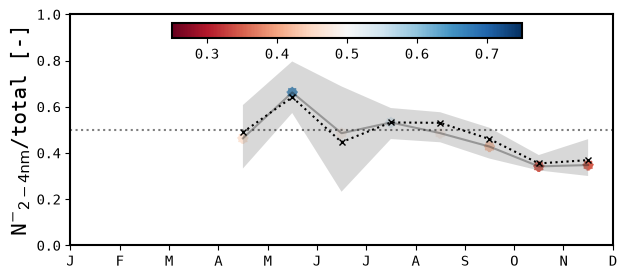

In [63]:
df_neg_pos_M = df_neg_pos.groupby('month').agg({'neg_total_ratio': [q50, q25, q75, 'mean', 'count']})
df_neg_pos_M.columns = ['q50', 'q25', 'q75', 'mean', 'count']
fig = plot_ratio(df_neg_pos_M, ylabel='N$^{-}$$_{2-4\\mathrm{nm}}$/total [-]', cmap_RdBu=True)

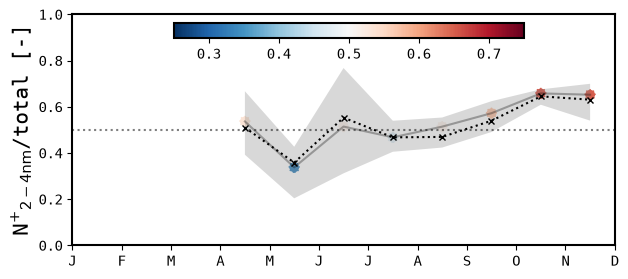

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_6.jpeg


In [64]:
df_neg_pos_M = df_neg_pos.groupby('month').agg({'pos_total_ratio': [q50, q25, q75, 'mean', 'count']})
df_neg_pos_M.columns = ['q50', 'q25', 'q75', 'mean', 'count']
fig = plot_ratio(df_neg_pos_M, ylabel='N$^{+}$$_{2-4\\mathrm{nm}}$/total [-]')

output_figure = plots_outpath / 'Figure_6.jpeg'
save_plot(fig, output_figure)

In [65]:
def get_df_ratios(date_ratios):
    df_ratios = pd.DataFrame(date_ratios.items(), columns=['date', 'ratio_neg_pos_2_4nm'])
    df_ratios = df_ratios.set_index('date')
    df_ratios.index = pd.to_datetime(df_ratios.index)
    df_ratios['month'] = df_ratios.index.month
    return df_ratios

df_ratios = get_df_ratios(date_neg_total_ratios)
df_ratios_M = df_ratios.groupby('month').agg({'ratio_neg_pos_2_4nm': [q50, q25, q75, 'mean', 'count']})
df_ratios_M.columns = ['q50', 'q25', 'q75', 'mean', 'count']

df_neg_pos=df_neg_pos.replace(0, np.nan)

In [66]:
def ratio_neg_total_timeseries(df_neg_pos):
    fig, ax = plt.subplots(figsize=(10, 2))
    ax.plot(df_neg_pos.index, df_neg_pos['neg_total_ratio'].values, 'o', ms=1)
    ax.axhline(y=0.5)
    ax.plot(df_neg_pos.index, df_neg_pos['neg_total_ratio'].rolling(window=4, center=True, 
                                                                    min_periods=2).mean(), label='')
    ax.set_ylabel('Ratio (neg/total)')
    ax.set_title('neg/total')
    plt.show()
    return fig

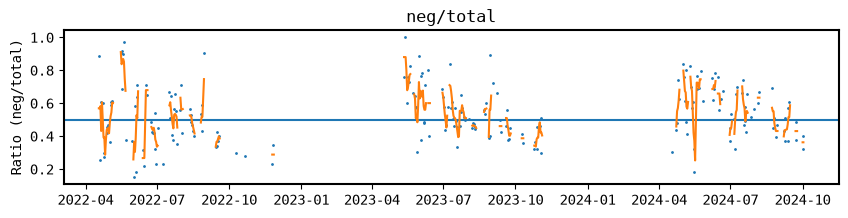

In [67]:
fig = ratio_neg_total_timeseries(df_neg_pos)

In [68]:
savepath_airion_rations = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\air_ion_ratios'
df_neg_pos.to_csv(savepath_airion_rations+'\\'+'air_ion_ratios_bytotal.dat', index=True)

df_neg_pos.index = df_neg_pos.index.map(lambda x: x.replace(year=2024))
df_neg_pos = df_neg_pos.sort_index()

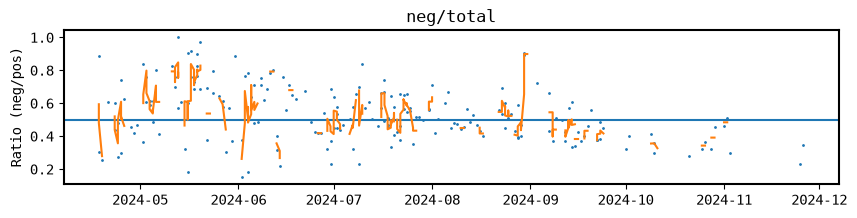

In [69]:
fig, ax = plt.subplots(figsize=(10, 2))
ax.plot(df_neg_pos.index, df_neg_pos['neg_total_ratio'].values, 'o', ms=1)
ax.axhline(y=0.5)
ax.plot(df_neg_pos.index, df_neg_pos['neg_total_ratio'].rolling(window=4, center=True, min_periods=2).mean(), label='')
ax.set_ylabel('Ratio (neg/pos)')
ax.set_title('neg/total')
plt.show()

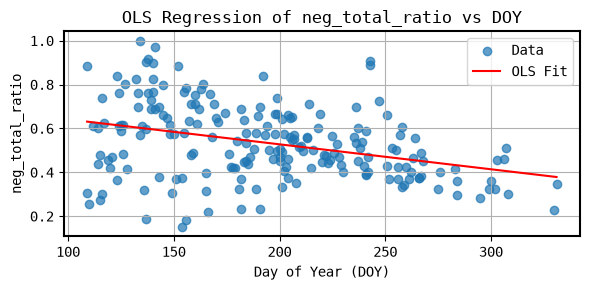

In [70]:
df = df_neg_pos.copy()
df['DOY'] = df.index.dayofyear
df = df[['DOY', 'neg_total_ratio']].copy()
df = df.dropna(how='any')
# Extract X and Y
x = df['DOY']
y = df['neg_total_ratio']
# Perform linear regression (OLS)
slope, intercept, r_value, p_value, std_err = linregress(x, y)
# Generate predicted y values
y_fit = slope * x + intercept

plt.figure(figsize=(6, 3))
plt.scatter(x, y, label='Data', alpha=0.7)
plt.plot(x, y_fit, color='red', label='OLS Fit')
plt.xlabel('Day of Year (DOY)')
plt.ylabel('neg_total_ratio')
plt.title('OLS Regression of neg_total_ratio vs DOY')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [71]:
# Calculate DOY when y = 0.5 on the OLS line
doy_at_0_5 = (0.5 - intercept) / slope
print(f"DOY when OLS line crosses y=0.5: {doy_at_0_5:.2f}")
reference_year = 2022
date_at_0_5 = datetime(reference_year, 1, 1) + timedelta(days=doy_at_0_5 - 1)
print(date_at_0_5)

DOY when OLS line crosses y=0.5: 224.24
2022-08-12 05:41:17.370682


In [72]:
# Beck data
loadpath_beck_data = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\beck_data'
beck_NyA = scipy.io.loadmat(loadpath_beck_data+'\\'+'Figure1_Villum_NyAlesund.mat')

beck_NyA_time = pd.DataFrame(np.reshape(beck_NyA['NYA_vapours_time'], (155,1)), columns=['NYA_vapours_time'])
beck_NyA_HOM = pd.DataFrame(beck_NyA['NYA_HOM'], columns=['NYA_HOM'])
beck_NyA_IA = pd.DataFrame(beck_NyA['NYA_IA'], columns=['NYA_IA'])
beck_NyA_MSA = pd.DataFrame(beck_NyA['NYA_MSA'], columns=['NYA_MSA'])
beck_NyA_SA = pd.DataFrame(beck_NyA['NYA_SA'], columns=['NYA_SA'])
df_beck = pd.concat([beck_NyA_time, beck_NyA_HOM, beck_NyA_IA, beck_NyA_MSA, beck_NyA_SA], axis=1)
df_beck = df_beck.dropna(how='all')

start_date=pd.to_datetime('2017-03-28')
end_date=pd.to_datetime('2017-08-31')
offset=6 #get it right with plot
dates = pd.date_range(start_date-timedelta(days=offset), end_date-timedelta(days=2)-timedelta(days=offset),freq='d')

df_beck.loc[:,'dates'] = dates
df_beck = df_beck.set_index('dates')

df_beck['totalvapours'] = df_beck[['NYA_HOM', 'NYA_IA', 'NYA_MSA', 'NYA_SA']].sum(axis=1)
df_beck['HOMS_total'] = df_beck['NYA_HOM']/df_beck['totalvapours']

C:\Users\Dell\AppData\Local\Temp\ipykernel_22268\1132961983.py:16: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  dates = pd.date_range(start_date-timedelta(days=offset), end_date-timedelta(days=2)-timedelta(days=offset),freq='d')


In [73]:
savepath_beck_data = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\beck_data'
df_beck.to_csv(savepath_beck_data+'\\'+'beck_data.dat', index=True)

In [74]:
#Ny-Ålesund from April 12 to May 26, 2017. March 2017 until the end of August 2017
def ratio_homes_ions(df_beck, df_neg_pos):
    df_beck.index = df_beck.index.map(lambda x: x.replace(year=2024))
    fig, ax = plt.subplots(figsize=(7, 3))
    ax2 = ax.twinx()
    ax2.plot(df_beck['NYA_SA'].index, df_beck['HOMS_total'].values, '--', c='k')
    ax2.set_ylim(0,1)
    ax.set_ylabel('Ratio HOMS/Tot [-]')
    ax2.plot(df_neg_pos.index, df_neg_pos['pos_total_ratio'].values, 'o', ms=5, mfc='None')
    ax2.axhline(y=0.5)
    ax2.set_ylabel('Ratio (pos/total)')
    plt.show()
    return fig

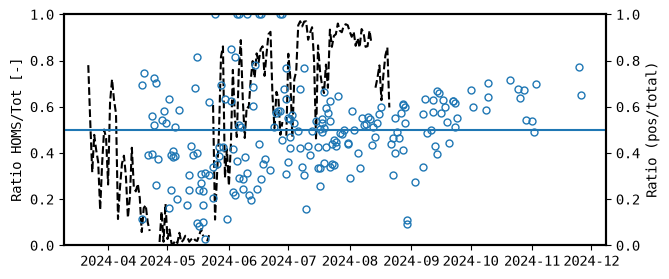

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_S24.jpeg


In [75]:
fig = ratio_homes_ions(df_beck, df_neg_pos)
output_figure = plots_outpath / 'Figure_S24.jpeg'
save_plot(fig, output_figure)